# **Dynamic Freight Spot-Pricing Engine**

**Objective** : The goal of this pipeline is to generate **real-time, per-kilogram spot price estimations** ($\hat{P}_{\text{spot}}$) for incoming air cargo requests. The pricing engine dynamically adjusts rates by integrating active terminal capacity, shipment priority surcharges, operational risk metrics, and short-term jet fuel price trends.

## **Architecture & Target Engineering Methodology**

Because raw transactional logs track operational expenditures rather than historical market spot quotes, we construct a synthetic target variable—the **Dynamic Spot Price per Kilogram** ($Y_{i}$)—derived from base handling costs and dynamic surge multipliers.

**Base Operational Rate** : The foundational cost per kilogram for record $i$ is derived from total operational costs and cargo mass ($V_i$, converted to kilograms):

$$\text{Base Cost}_i = \frac{\text{Operational\_Cost}_i}{1000 \times \text{Cargo\_Volume}_i}$$

### **Dynamic Surge Multiplier**
The pricing adjustment factor $\mathcal{M}_i$ synthesizes three primary operational vectors:
1. **Priority Factor ($\gamma_{\text{priority}}$)**: Service-level mapping for priority tiers ($\text{Low} \to 1.0$, $\text{Medium} \to 1.15$, $\text{High} \to 1.35$, $\text{Critical} \to 1.60$).
2. **Capacity Strain ($\mathcal{C}_i$)**: Supply-demand friction measured via terminal metrics:
   $$\mathcal{C}_i = 1 + \alpha \cdot \text{Facility\_Utilization}_i + \beta \cdot \text{Bottleneck\_Flag}_i$$
   *(where $\alpha = 0.30$ and $\beta = 0.20$ calibrate utilization scaling and queue delays).*
3. **Jet Fuel Index ($\mathcal{F}_t$)**: Exponentially smoothed time-series component tracking fuel volatility:
   $$\mathcal{F}_t = \lambda F_t + (1 - \lambda) \mathcal{F}_{t-1}$$

**Target Feature Formula** : Combining these components yields the final regression target $Y_i$ (in $\text{USD/kg}$):

$$Y_i = \text{Base Cost}_i \times \gamma_{\text{priority}, i} \times \mathcal{C}_i \times \mathcal{F}_t$$

## **Predictive Modeling Framework**
* **CatBoost Regression**: Chosen for its native handling of high-cardinality categorical inputs (`Flight_ID`, `Terminal_ID`, `Cargo_Type`, `Shipment_Priority`) without requiring explicit target encoding preprocessing.
* **Prophet Integration**: Deployed upstream to decompose macro temporal trends, seasonal peaks (e.g., Q4 shipping rushes), and baseline volume fluctuations across the dataset's `Timestamp` sequences.

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
from matplotlib import pyplot as plt

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/colabsss/air-cargo-resource-allocation-data/air_cargo_resource_allocation_dataset.csv


In [2]:
data = pd.read_csv('/kaggle/input/datasets/colabsss/air-cargo-resource-allocation-data/air_cargo_resource_allocation_dataset.csv')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 28 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Record_ID                    5000 non-null   int64  
 1   Timestamp                    5000 non-null   object 
 2   Flight_ID                    5000 non-null   object 
 3   Cargo_Volume                 5000 non-null   float64
 4   Cargo_Type                   5000 non-null   object 
 5   Shipment_Priority            5000 non-null   object 
 6   Arrival_Departure            5000 non-null   object 
 7   Terminal_ID                  5000 non-null   object 
 8   Gate_Assigned                5000 non-null   int64  
 9   Handling_Time                5000 non-null   float64
 10  Waiting_Time                 5000 non-null   float64
 11  Workforce_Assigned           5000 non-null   int64  
 12  Equipment_Used               5000 non-null   int64  
 13  Equipment_Type    

In [3]:
data.head()

,Record_ID,Timestamp,Flight_ID,Cargo_Volume,Cargo_Type,Shipment_Priority,Arrival_Departure,Terminal_ID,Gate_Assigned,Handling_Time,...,Peak_Hour_Indicator,Weather_Condition,Operational_Cost,Energy_Consumption,Throughput_Rate,Bottleneck_Flag,Demand_Forecast,Real_Time_Load,Allocation_Strategy,Allocation_Efficiency_Class
0,1,2024-03-22 01:39:00,FL8546,48.07,Hazardous,Medium,Arrival,T4,17,23.24,...,0,Clear,1362.30,487.29,83.04,0,118.29,28.15,Optimized,Moderate Efficiency
1,2,2024-01-19 05:05:00,FL9797,114.33,Express,High,Departure,T2,32,106.85,...,0,Clear,1193.42,602.07,25.17,1,123.53,70.81,Optimized,Low Efficiency
2,3,2024-07-19 06:29:00,FL6490,89.18,Hazardous,Low,Arrival,T1,46,165.06,...,0,Storm,4419.53,970.64,99.91,1,12.72,27.26,Baseline,Low Efficiency
3,4,2024-06-27 07:47:00,FL8577,73.85,Express,Low,Departure,T4,7,49.02,...,0,Rain,4832.66,1024.58,18.09,1,140.04,80.36,Optimized,Low Efficiency
4,5,2024-06-11 12:53:00,FL7782,22.94,Express,Medium,Departure,T1,39,76.42,...,0,Fog,3300.43,219.50,22.47,1,136.87,18.60,Adaptive,Low Efficiency


In [4]:
data.isnull().sum()

Record_ID                      0
Timestamp                      0
Flight_ID                      0
Cargo_Volume                   0
Cargo_Type                     0
Shipment_Priority              0
Arrival_Departure              0
Terminal_ID                    0
Gate_Assigned                  0
Handling_Time                  0
Waiting_Time                   0
Workforce_Assigned             0
Equipment_Used                 0
Equipment_Type                 0
Facility_Utilization           0
Storage_Occupancy              0
Queue_Length                   0
Flight_Delay                   0
Peak_Hour_Indicator            0
Weather_Condition              0
Operational_Cost               0
Energy_Consumption             0
Throughput_Rate                0
Bottleneck_Flag                0
Demand_Forecast                0
Real_Time_Load                 0
Allocation_Strategy            0
Allocation_Efficiency_Class    0
dtype: int64

## **Exploratory Data Analysis**

/tmp/ipykernel_16/692336978.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x='Cargo_Type', ax=axs[0], palette='crest')


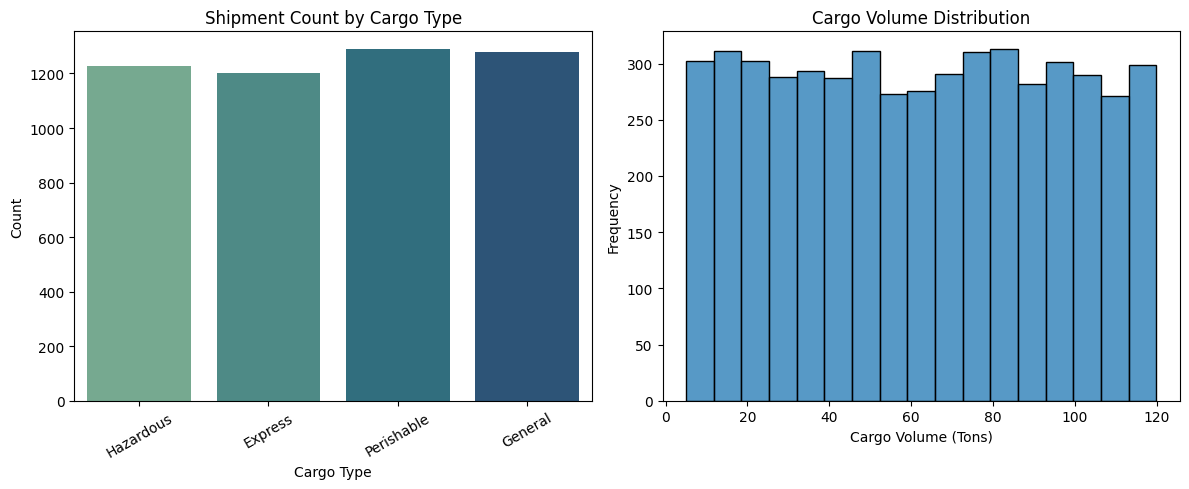

In [5]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# 1. Count plot for categorical column (Cargo_Type)
sns.countplot(data=data, x='Cargo_Type', ax=axs[0], palette='crest')
axs[0].set_title('Shipment Count by Cargo Type')
axs[0].set_xlabel('Cargo Type')
axs[0].set_ylabel('Count')
axs[0].tick_params(axis='x', rotation=30)

# 2. Distribution plot for continuous column (Cargo_Volume)
sns.histplot(data=data, x='Cargo_Volume', ax=axs[1])
axs[1].set_title('Cargo Volume Distribution')
axs[1].set_xlabel('Cargo Volume (Tons)')
axs[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

/tmp/ipykernel_16/1160024868.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Shipment_Priority', y='Cost_per_Ton', palette='Set2')


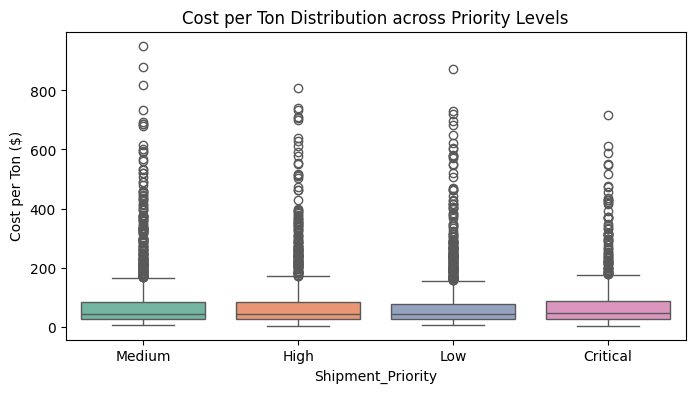

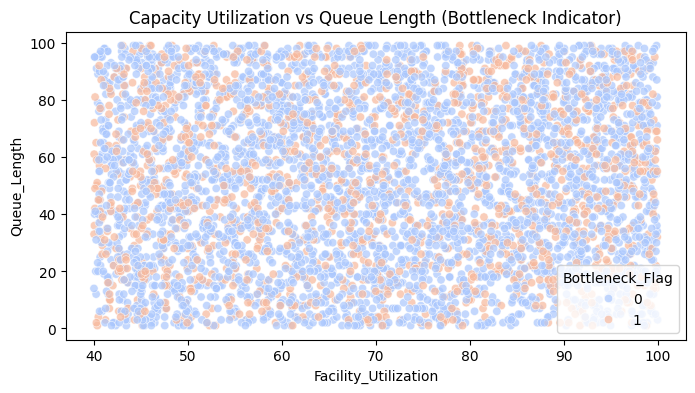

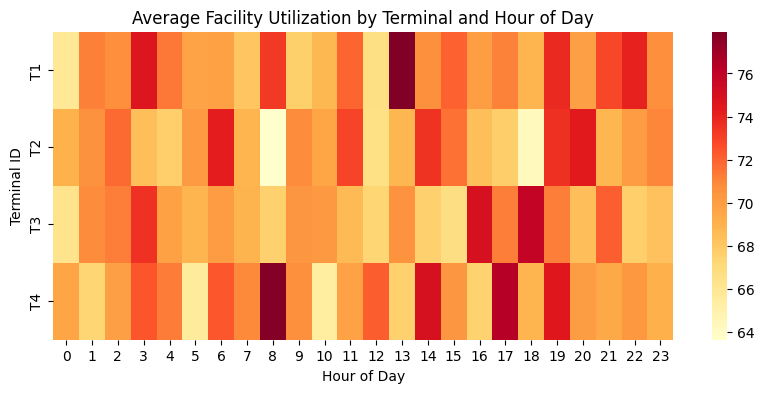

In [6]:
# 1. Cost per Volume by Priority Tier
data['Cost_per_Ton'] = data['Operational_Cost'] / data['Cargo_Volume']

plt.figure(figsize=(8, 4))
sns.boxplot(data=data, x='Shipment_Priority', y='Cost_per_Ton', palette='Set2')
plt.title('Cost per Ton Distribution across Priority Levels')
plt.ylabel('Cost per Ton ($)')
plt.show()

# 2. Facility Utilization Tipping Point vs Queue Length
plt.figure(figsize=(8, 4))
sns.scatterplot(
    data=data, 
    x='Facility_Utilization', 
    y='Queue_Length', 
    hue='Bottleneck_Flag', 
    palette='coolwarm',
    alpha=0.7
)
plt.title('Capacity Utilization vs Queue Length (Bottleneck Indicator)')
plt.show()

# 3. Peak Hour Congestion Heatmap by Terminal
data['Timestamp'] = pd.to_datetime(data['Timestamp'])
data['Hour'] = data['Timestamp'].dt.hour

pivot_util = data.pivot_table(index='Terminal_ID', columns='Hour', values='Facility_Utilization', aggfunc='mean')

plt.figure(figsize=(10, 4))
sns.heatmap(pivot_util, cmap='YlOrRd', annot=False)
plt.title('Average Facility Utilization by Terminal and Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Terminal ID')
plt.show()

## **Feature Engineering & Scaling**

In [7]:
# 1. Temporal feature engineeirng and cyclical encoding

# Parse timestamp
data['Timestamp'] = pd.to_datetime(data['Timestamp'])

# Extract temporal components
data['Hour'] = data['Timestamp'].dt.hour
data['DayOfWeek'] = data['Timestamp'].dt.dayofweek
data['Month'] = data['Timestamp'].dt.month

# Cyclical Encoding for Hour of Day (preserves continuity between 23:00 and 00:00)
data['Hour_Sin'] = np.sin(2 * np.pi * data['Hour'] / 24.0)
data['Hour_Cos'] = np.cos(2 * np.pi * data['Hour'] / 24.0)

# Cyclical Encoding for Day of Week
data['DayOfWeek_Sin'] = np.sin(2 * np.pi * data['DayOfWeek'] / 7.0)
data['DayOfWeek_Cos'] = np.cos(2 * np.pi * data['DayOfWeek'] / 7.0)

# High-cardinality interaction feature for terminal peak-hour modeling
data['Terminal_Hour'] = data['Terminal_ID'].astype(str) + '_H' + data['Hour'].astype(str)


# 2. operational interaction and constraints feature engineering

# Convert Cargo_Volume from metric tons to kilograms
data['Cargo_Volume_KG'] = data['Cargo_Volume'] * 1000.0

# Base operational cost per kilogram
data['Base_Cost_per_KG'] = data['Operational_Cost'] / data['Cargo_Volume_KG']

# Interaction term to force non-linear bottleneck signals into tree splits
data['Utilization_Queue_Interaction'] = (data['Facility_Utilization'] / 100.0) * data['Queue_Length']

# Capacity Strain Factor (C_i)
alpha, beta = 0.30, 0.20
data['Capacity_Strain'] = 1.0 + (alpha * (data['Facility_Utilization'] / 100.0)) + (beta * data['Bottleneck_Flag'])

# Priority factor map
priority_map = {'Low': 1.00, 'Medium': 1.15, 'High': 1.35, 'Critical': 1.60}
data['Priority_Factor'] = data['Shipment_Priority'].map(priority_map)



# 3. target feature synthesis and target scaling

# Synthesize Target Spot Price per KG (Y_i)
# Note: Plug in your exponentially smoothed fuel index array/column if merged
fuel_index_placeholder = 1.0 
data['Target_Spot_Price_per_KG'] = (
    data['Base_Cost_per_KG'] * data['Priority_Factor'] * data['Capacity_Strain'] * fuel_index_placeholder
)

# Feature Scaling: Apply Log1P transformation to target to compress upper outliers
data['Target_Spot_Price_Log'] = np.log1p(data['Target_Spot_Price_per_KG'])


# 4. prepare feature matrices for ML model
categorical_features = [
    'Flight_ID', 'Terminal_ID', 'Cargo_Type', 
    'Shipment_Priority', 'Arrival_Departure', 'Terminal_Hour'
]

numerical_features = [
    'Cargo_Volume', 'Handling_Time', 'Waiting_Time', 
    'Workforce_Assigned', 'Facility_Utilization', 'Queue_Length', 
    'Storage_Occupancy', 'Flight_Delay', 'Hour_Sin', 'Hour_Cos', 
    'DayOfWeek_Sin', 'DayOfWeek_Cos', 'Utilization_Queue_Interaction'
]

X = data[categorical_features + numerical_features]
y = data['Target_Spot_Price_Log']

print("Dataset prepared successfully.")
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Dataset prepared successfully.
Features shape: (5000, 19)
Target shape: (5000,)


## **Model Construction & Performance Analysis**

In [8]:
from prophet import Prophet
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Model 1: Prophet time-series decomposition
print("Training Model 1: Prophet Time-Series Engine...")

# Prophet expects columns 'ds' (datestamp) and 'y' (target)
data_prophet = data[['Timestamp', 'Target_Spot_Price_per_KG']].rename(
    columns={'Timestamp': 'ds', 'Target_Spot_Price_per_KG': 'y'}
).sort_values('ds')

# Initialize and fit Prophet
prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=True,
    interval_width=0.95
)
prophet_model.fit(data_prophet)

# Generate Prophet in-sample trend predictions
forecast = prophet_model.predict(data_prophet[['ds']])
data['Prophet_Trend_Signal'] = forecast['yhat'].values


# Model 2: CatBoost regression engine
print("\nTraining Model 2: CatBoost Spot-Pricing Engine...")

# Append Prophet's trend signal as an upstream numeric feature
if 'Prophet_Trend_Signal' not in numerical_features:
    numerical_features.append('Prophet_Trend_Signal')

X = data[categorical_features + numerical_features]
y = data['Target_Spot_Price_Log']  # Log-transformed target

# Time-based train-test split (80% Train, 20% Test) to prevent data leakage
split_idx = int(len(data) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# Initialize CatBoost Regressor
catboost_model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    cat_features=categorical_features,
    loss_function='RMSE',
    eval_metric='RMSE',
    random_seed=42,
    verbose=100
)

# Fit CatBoost Model
catboost_model.fit(
    X_train, y_train,
    eval_set=(X_test, y_test),
    early_stopping_rounds=50,
    use_best_model=True
)

# Generate Predictions & Reverse Log Transformation to USD/kg
y_pred_log_catboost = catboost_model.predict(X_test)
y_pred_usd_catboost = np.expm1(y_pred_log_catboost)

y_pred_usd_prophet = forecast['yhat'].iloc[split_idx:].values
y_test_usd = np.expm1(y_test)

print("\nModel Training Complete!")

Training Model 1: Prophet Time-Series Engine...


13:46:16 - cmdstanpy - INFO - Chain [1] start processing
13:46:16 - cmdstanpy - INFO - Chain [1] done processing



Training Model 2: CatBoost Spot-Pricing Engine...
0:	learn: 0.1113067	test: 0.1153378	best: 0.1153378 (0)	total: 64.5ms	remaining: 1m 4s
100:	learn: 0.0580767	test: 0.0663279	best: 0.0663279 (100)	total: 747ms	remaining: 6.65s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.06607028279
bestIteration = 112

Shrink model to first 113 iterations.

Model Training Complete!


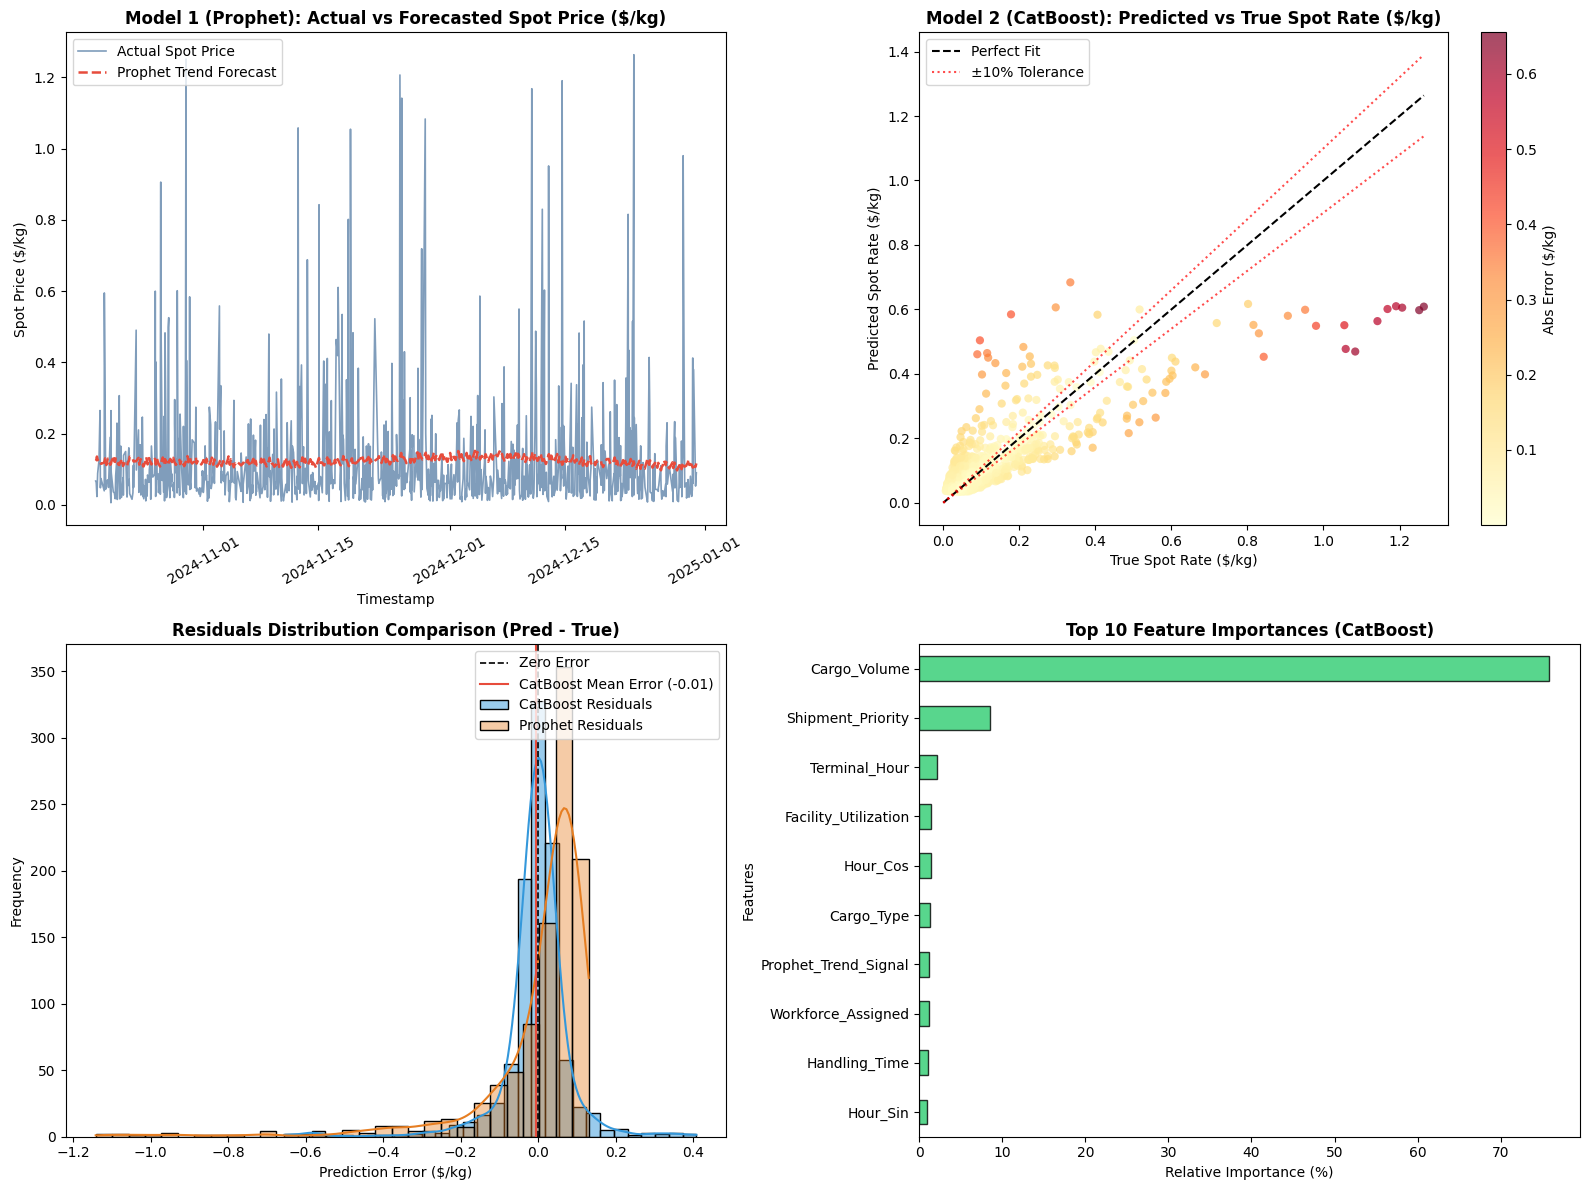


Model Evaluation Metrics Summary:
           Model  MAE ($/kg)  RMSE ($/kg)  R² Score
Prophet Baseline    0.096913     0.161709 -0.003125
 CatBoost Engine    0.052017     0.094389  0.658236


In [9]:
fig, axs = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Prophet actual vs predicted trend line
axs[0, 0].plot(data_prophet['ds'].iloc[split_idx:], y_test_usd, label='Actual Spot Price', color='#2b5c8f', alpha=0.6, linewidth=1.2)
axs[0, 0].plot(data_prophet['ds'].iloc[split_idx:], y_pred_usd_prophet, label='Prophet Trend Forecast', color='#e74c3c', linestyle='--', linewidth=1.8)
axs[0, 0].set_title('Model 1 (Prophet): Actual vs Forecasted Spot Price ($/kg)', fontsize=12, fontweight='bold')
axs[0, 0].set_xlabel('Timestamp')
axs[0, 0].set_ylabel('Spot Price ($/kg)')
axs[0, 0].legend(loc='upper left')
axs[0, 0].tick_params(axis='x', rotation=30)

# Plot 2: CatBoost predicted vs true spot price with error heatmap
abs_error_catboost = np.abs(y_test_usd - y_pred_usd_catboost)
max_val = max(y_test_usd.max(), y_pred_usd_catboost.max())

scatter = axs[0, 1].scatter(
    y_test_usd, y_pred_usd_catboost, 
    c=abs_error_catboost, cmap='YlOrRd', 
    alpha=0.7, edgecolors='none', s=35
)
# Perfect fit line
axs[0, 1].plot([0, max_val], [0, max_val], 'k--', label='Perfect Fit', linewidth=1.5)
# Error tolerance band (±10%)
axs[0, 1].plot([0, max_val], [0, max_val * 1.10], 'r:', label='±10% Tolerance', alpha=0.7)
axs[0, 1].plot([0, max_val], [0, max_val * 0.90], 'r:', alpha=0.7)

cbar = fig.colorbar(scatter, ax=axs[0, 1])
cbar.set_label('Abs Error ($/kg)')
axs[0, 1].set_title('Model 2 (CatBoost): Predicted vs True Spot Rate ($/kg)', fontsize=12, fontweight='bold')
axs[0, 1].set_xlabel('True Spot Rate ($/kg)')
axs[0, 1].set_ylabel('Predicted Spot Rate ($/kg)')
axs[0, 1].legend(loc='upper left')

# Plot 3: Residual error distribution comparison
residuals_catboost = y_pred_usd_catboost - y_test_usd
residuals_prophet = y_pred_usd_prophet - y_test_usd

sns.histplot(residuals_catboost, kde=True, ax=axs[1, 0], color='#3498db', label='CatBoost Residuals', bins=30, alpha=0.5)
sns.histplot(residuals_prophet, kde=True, ax=axs[1, 0], color='#e67e22', label='Prophet Residuals', bins=30, alpha=0.4)

mean_err_cat = np.mean(residuals_catboost)
axs[1, 0].axvline(0, color='black', linestyle='--', linewidth=1.2, label='Zero Error')
axs[1, 0].axvline(mean_err_cat, color='#e74c3c', linestyle='-', label=f'CatBoost Mean Error ({mean_err_cat:.2f})')

axs[1, 0].set_title('Residuals Distribution Comparison (Pred - True)', fontsize=12, fontweight='bold')
axs[1, 0].set_xlabel('Prediction Error ($/kg)')
axs[1, 0].set_ylabel('Frequency')
axs[1, 0].legend(loc='upper right')

# Plot 4: CatBoost top feature importance
feature_importances = pd.Series(
    catboost_model.get_feature_importance(), 
    index=X_train.columns
).sort_values(ascending=True).tail(10)

feature_importances.plot(kind='barh', ax=axs[1, 1], color='#2ecc71', edgecolor='black', alpha=0.8)
axs[1, 1].set_title('Top 10 Feature Importances (CatBoost)', fontsize=12, fontweight='bold')
axs[1, 1].set_xlabel('Relative Importance (%)')
axs[1, 1].set_ylabel('Features')

plt.tight_layout()
plt.show()

# Model comparison summary metrics
metrics_data = pd.DataFrame({
    'Model': ['Prophet Baseline', 'CatBoost Engine'],
    'MAE ($/kg)': [
        mean_absolute_error(y_test_usd, y_pred_usd_prophet),
        mean_absolute_error(y_test_usd, y_pred_usd_catboost)
    ],
    'RMSE ($/kg)': [
        np.sqrt(mean_squared_error(y_test_usd, y_pred_usd_prophet)),
        np.sqrt(mean_squared_error(y_test_usd, y_pred_usd_catboost))
    ],
    'R² Score': [
        r2_score(y_test_usd, y_pred_usd_prophet),
        r2_score(y_test_usd, y_pred_usd_catboost)
    ]
})

print("\nModel Evaluation Metrics Summary:")
print(metrics_data.to_string(index=False))